<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework32.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Prac 03. Part 2
This notebook contains task from Prac_03_Tasks.pdf: the manual filtration implementation and its visual comparison with OpenCV

blur filter
sharpening filter
median filter
erosion and dilation filter
Sobel filter

In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

In [7]:
!wget  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png

--2026-05-22 14:29:52--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/pic31.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 736501 (719K) [image/png]
Saving to: ‘pic31.png.1’

pic31.png.1         100%[===================>] 719.24K  --.-KB/s    in 0.03s   

2026-05-22 14:29:52 (24.0 MB/s) - ‘pic31.png.1’ saved [736501/736501]



In [8]:
# Set default figure size for better visualization
plt.rcParams['figure.figsize'] = [15, 15]

# Load the image and convert it to RGB color space
img = cv2.imread('pic31.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Manual Convolution Implementation

In [9]:
def manual_convolve(image, kernel):
    """
    Applies a 2D convolution kernel to an RGB image manually.
    """
    k_h, k_w = kernel.shape
    pad_h, pad_w = k_h // 2, k_w // 2

    # Pad the image to handle border pixels correctly (using edge padding)
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w), (0, 0)), mode='edge')

    # Create an empty float32 array to accumulate the convolution sum
    out = np.zeros_like(image, dtype=np.float32)

    # Perform the convolution using vectorized operations over the image dimensions
    for y in range(k_h):
        for x in range(k_w):
            out += padded[y:y+image.shape[0], x:x+image.shape[1], :] * kernel[y, x]

    # Clip values to valid [0, 255] range and cast back to uint8
    return np.clip(out, 0, 255).astype(np.uint8)

Defining Kernels and Applying Filters


In [10]:
# 1. Blur Filter
kernel_blur = np.ones((3, 3)) / 9
manual_blur = manual_convolve(img, kernel_blur)
cv2_blur = cv2.blur(img, (3, 3))

# 2. Sharpen Filter
kernel_sharpen = np.array([
    [-1, -1, -1],
    [-1,  9, -1],
    [-1, -1, -1]
])
manual_sharpen = manual_convolve(img, kernel_sharpen)
cv2_sharpen = cv2.filter2D(img, -1, kernel_sharpen)

# 3. Sobel X Filter (Edge Detection)
kernel_sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
manual_sobel = manual_convolve(img, kernel_sobel_x)
# Using filter2D for a direct mathematical comparison with the exact same kernel
cv2_sobel = cv2.filter2D(img, -1, kernel_sobel_x)

Comparision

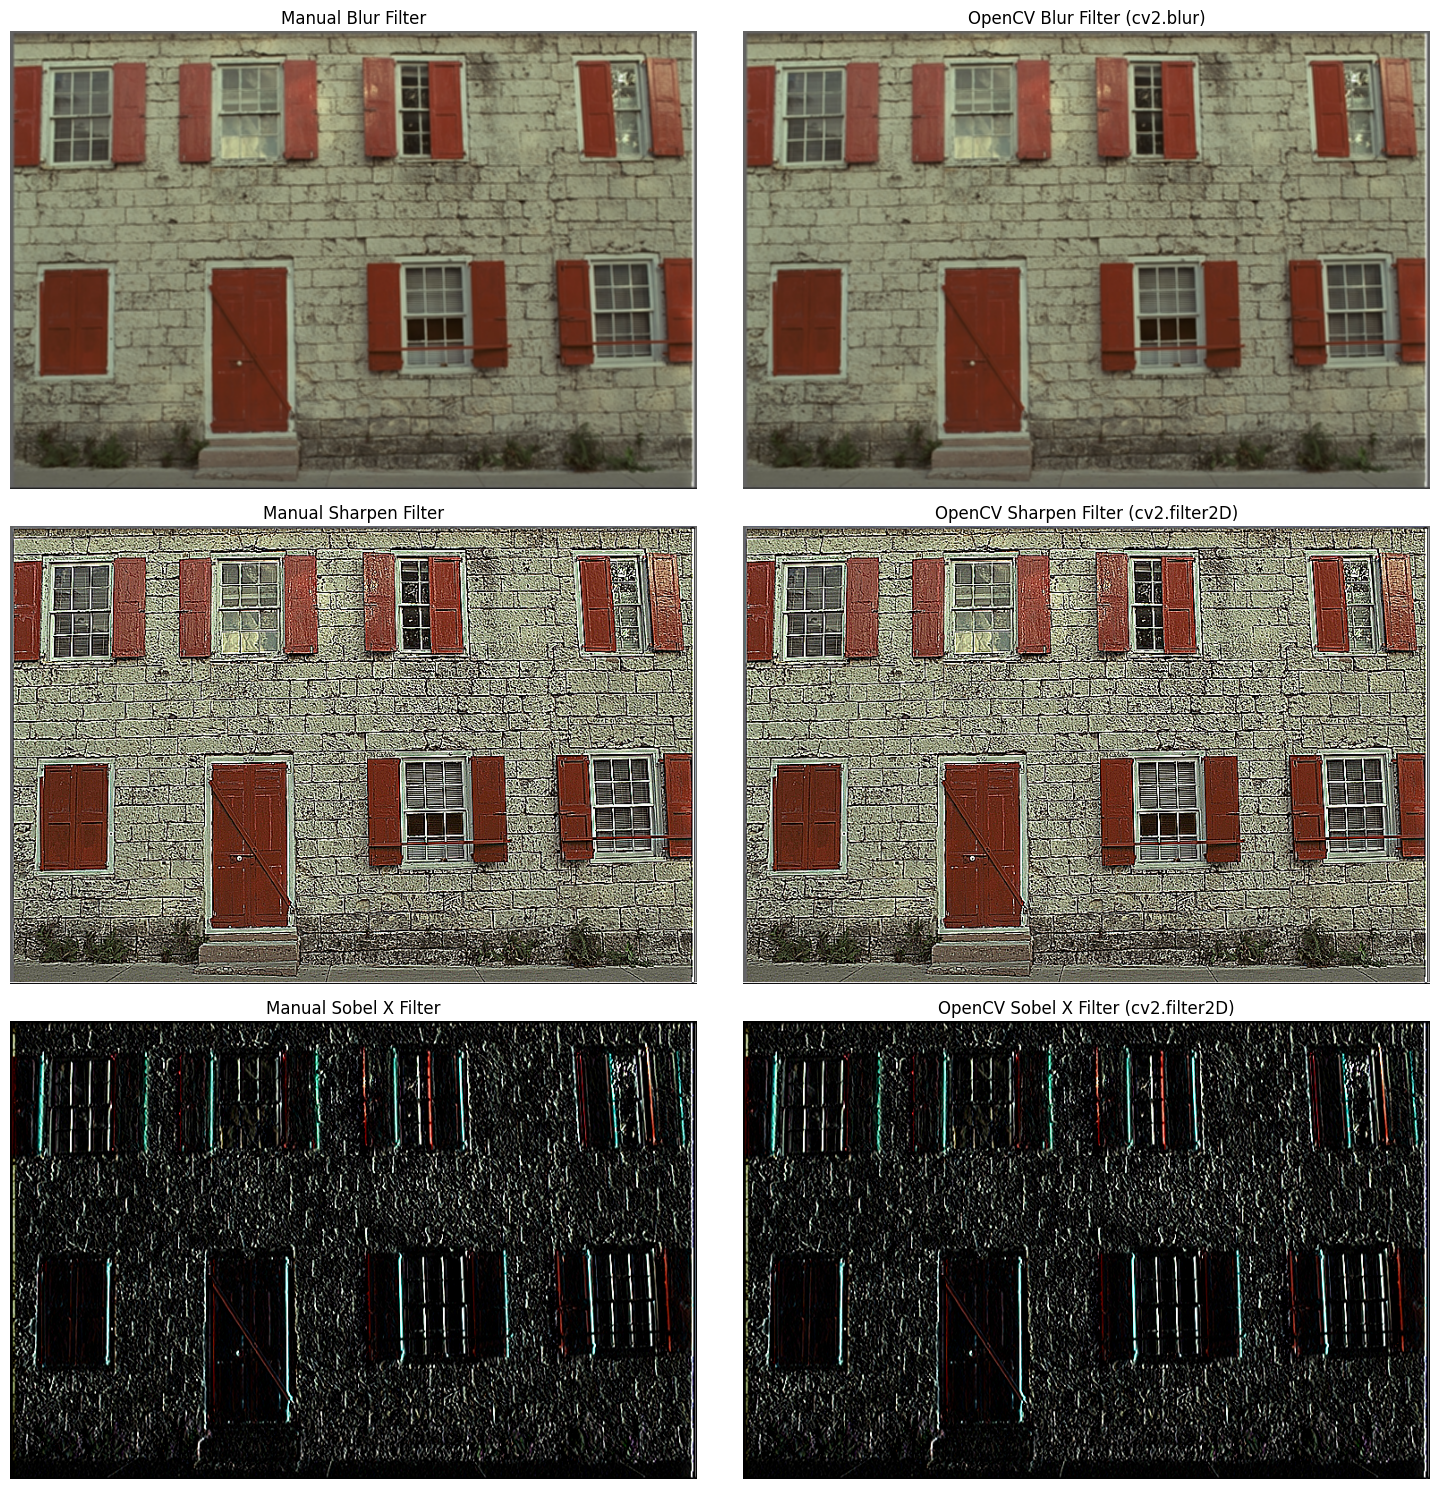

In [11]:
fig, axs = plt.subplots(3, 2)

# Row 1: Blur
axs[0, 0].imshow(manual_blur)
axs[0, 0].set_title("Manual Blur Filter")
axs[0, 0].axis('off')

axs[0, 1].imshow(cv2_blur)
axs[0, 1].set_title("OpenCV Blur Filter (cv2.blur)")
axs[0, 1].axis('off')

# Row 2: Sharpen
axs[1, 0].imshow(manual_sharpen)
axs[1, 0].set_title("Manual Sharpen Filter")
axs[1, 0].axis('off')

axs[1, 1].imshow(cv2_sharpen)
axs[1, 1].set_title("OpenCV Sharpen Filter (cv2.filter2D)")
axs[1, 1].axis('off')

# Row 3: Sobel X
axs[2, 0].imshow(manual_sobel)
axs[2, 0].set_title("Manual Sobel X Filter")
axs[2, 0].axis('off')

axs[2, 1].imshow(cv2_sobel)
axs[2, 1].set_title("OpenCV Sobel X Filter (cv2.filter2D)")
axs[2, 1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
def get_neighborhood_stack(image, kernel_size=3):
    """ Helper function to extract shifted image patches for non-linear filters """
    pad = kernel_size // 2
    padded = np.pad(image, ((pad, pad), (pad, pad), (0, 0)), mode='edge')
    neighbors = []

    for y in range(kernel_size):
        for x in range(kernel_size):
            neighbors.append(padded[y:y+image.shape[0], x:x+image.shape[1], :])

    # Stack all shifted versions along a new axis
    return np.stack(neighbors, axis=-1)

def manual_median(image, kernel_size=3):
    """ Applies a median filter manually (Non-linear). """
    stacked = get_neighborhood_stack(image, kernel_size)
    return np.median(stacked, axis=-1).astype(np.uint8)

def manual_erosion(image, kernel_size=3):
    """ Applies an erosion (minimum) filter manually (Non-linear). """
    stacked = get_neighborhood_stack(image, kernel_size)
    return np.min(stacked, axis=-1).astype(np.uint8)

def manual_dilation(image, kernel_size=3):
    """ Applies a dilation (maximum) filter manually (Non-linear). """
    stacked = get_neighborhood_stack(image, kernel_size)
    return np.max(stacked, axis=-1).astype(np.uint8)

In [13]:
# 4. Median Filter
manual_med = manual_median(img, kernel_size=3)
cv2_med = cv2.medianBlur(img, 3)

# 5. Erosion Filter
morph_kernel = np.ones((3, 3), np.uint8)
manual_erode = manual_erosion(img, kernel_size=3)
cv2_erode = cv2.erode(img, morph_kernel, iterations=1)

# 6. Dilation Filter
manual_dilate = manual_dilation(img, kernel_size=3)
cv2_dilate = cv2.dilate(img, morph_kernel, iterations=1)

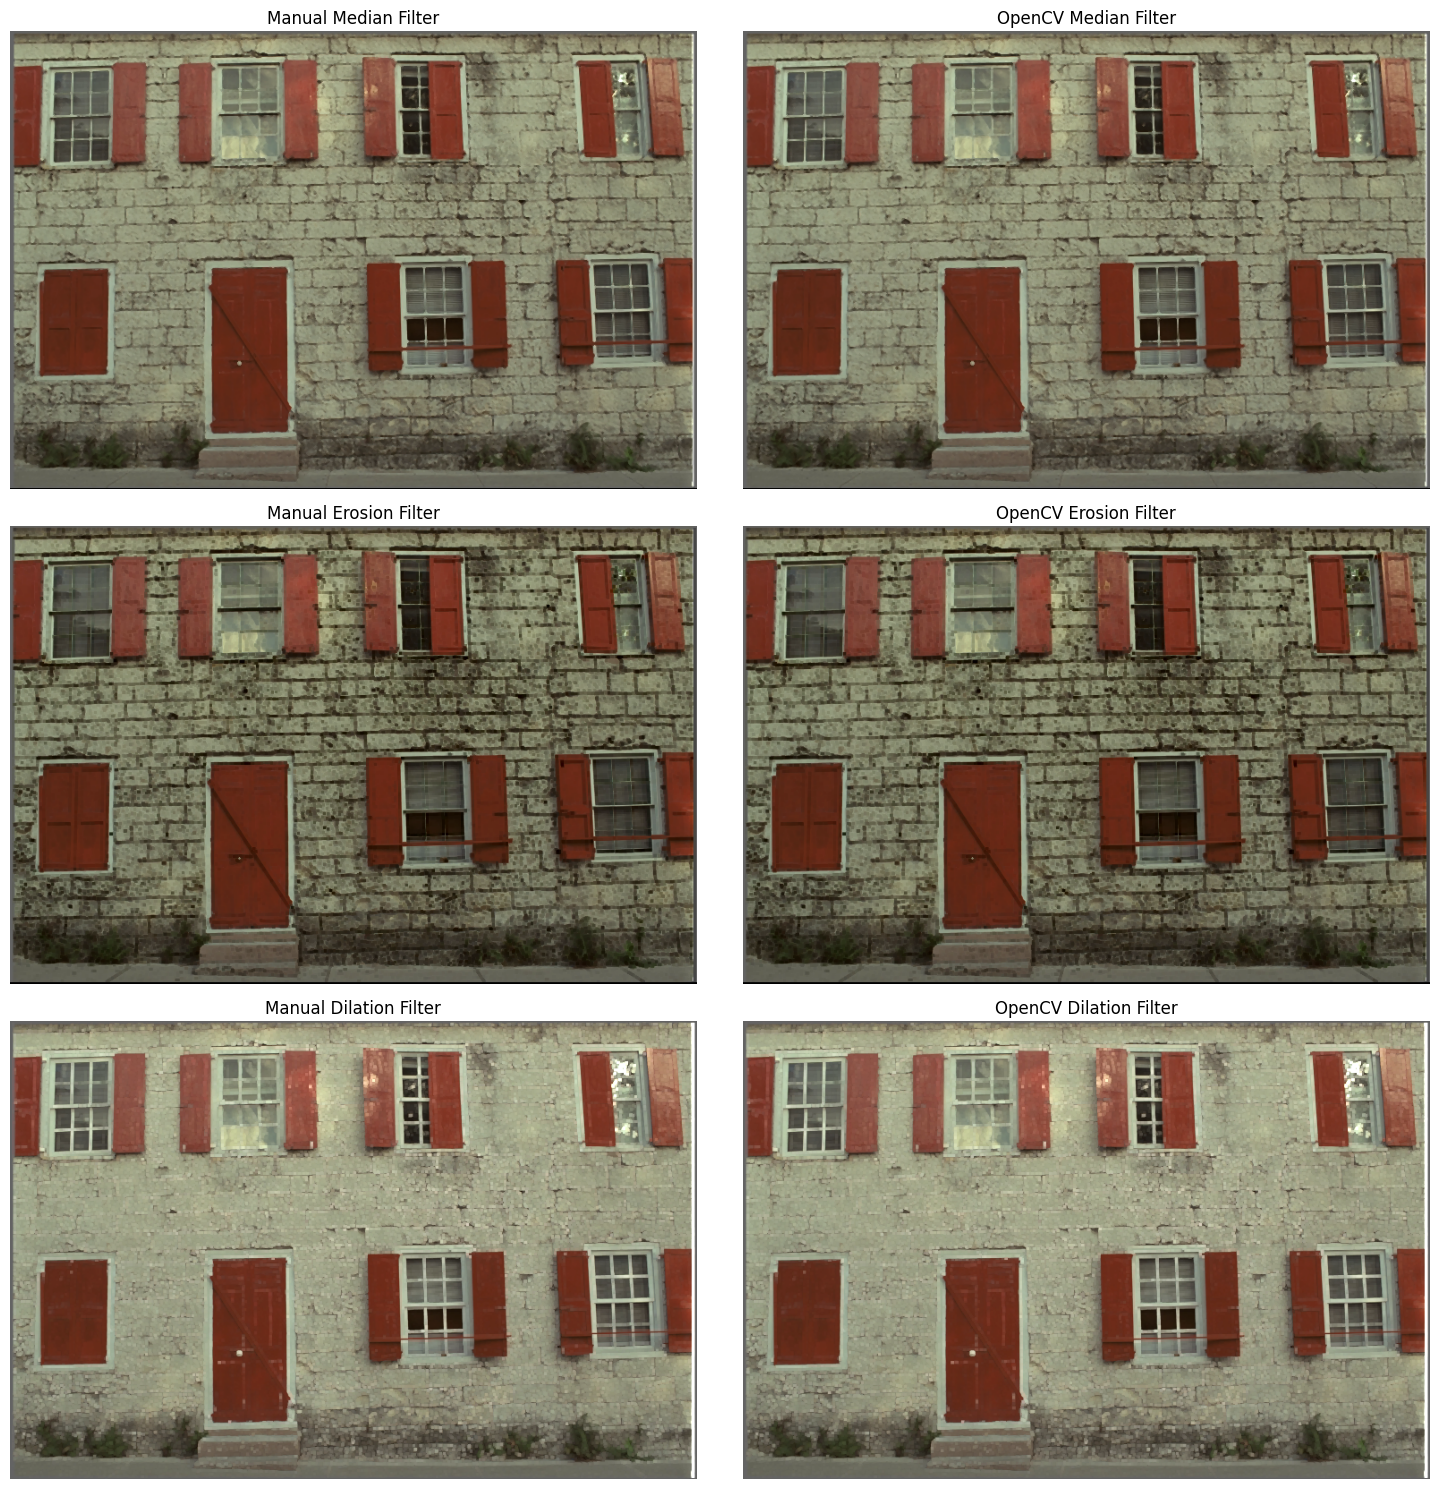

In [14]:
fig, axs = plt.subplots(3, 2)
titles_manual = [
    "Manual Median Filter", "Manual Erosion Filter", "Manual Dilation Filter"
]
titles_cv2 = [
    "OpenCV Median Filter", "OpenCV Erosion Filter", "OpenCV Dilation Filter"
]
images_manual = [manual_med, manual_erode, manual_dilate]
images_cv2 = [cv2_med, cv2_erode, cv2_dilate]

for i in range(3):
    axs[i, 0].imshow(images_manual[i])
    axs[i, 0].set_title(titles_manual[i])
    axs[i, 0].axis('off')

    axs[i, 1].imshow(images_cv2[i])
    axs[i, 1].set_title(titles_cv2[i])
    axs[i, 1].axis('off')

plt.tight_layout()
plt.show()